# Makemore 4：成为 backprop 忍者

[视频](https://www.youtube.com/watch?v=q8SA3rM6ckI)<br>
[代码仓库](https://github.com/karpathy/makemore)<br>
[Eureka Labs Discord](https://discord.com/invite/3zy8kqD9Cp)

## 目录

- [为什么要如此深入地关注 backprop？](#为什么要如此深入地关注-backprop)
    - [示例 - 用于双向图像-句子映射的深度片段嵌入](#示例---用于双向图像-句子映射的深度片段嵌入)
- [练习 1 - 反向传播](#练习-1---反向传播)
    - [1 - Logprobs](#1---logprobs)
    - [2 - Probs](#2---probs)
    - [3 - Counts_Sum_Inv](#3---counts_sum_inv)
    - [5.1 - Counts](#51---counts)
    - [4 - Counts_Sum](#4---counts_sum)
    - [5.2 - Counts](#52---counts)
    - [6 - Norm_Logits](#6---norm_logits)
    - [7 - Logit_Maxes](#7---logit_maxes)
    - [8 - Logits](#8---logits)
    - [9 - h、W2 和 b2（线性层的反向传播）](#9---h-w2-和-b2通过线性层的反向传播)
    - [10 - hpreact](#10---hpreact)
    - [11 - bngain、bnraw、bnbias](#11---bngain-bnraw-bnbias)
    - [12 - bndiff、bnvar_inv（BatchNorm 层）](#12---bndiff-bnvar_invbatchnorm-层)
    - [13 - bnvar](#13---bnvar)
    - [贝塞尔校正](#贝塞尔校正)
    - [14 - bndiff2](#14---bndiff2)
    - [15 - bndiff](#15---bndiff)
    - [16 - bnmeani](#16---bnmeani)
    - [17 - hprebn](#17---hprebn)
    - [18 - embcat、W1、b1（线性层）](#18---embcat-w1-b1-线性层)
    - [19 - emb](#19---emb)
    - [20 - C](#20---c)
- [练习 2 - 简化损失函数](#练习-2---简化损失)
    - [插曲：dlogits 是什么？](#插曲dlogits-是什么)
- [练习 3 - 简化 BatchNorm](#练习-3---化简-batchnorm)
    - [步骤 1](#第-1-步)
    - [步骤 2](#第-2-步)
    - [步骤 3](#第-3-步)
    - [步骤 4](#第-4-步)

<style>
/* Keep notebook content printable without horizontal clipping. */
.jp-OutputArea-output img,
.jp-RenderedImage img,
img {
  max-width: 100% !important;
  height: auto !important;
}

.jp-Cell,
.jp-InputArea,
.jp-OutputArea-output,
.jp-RenderedMarkdown,
.text_cell_render,
.rendered_html {
  overflow-wrap: anywhere !important;
  word-break: break-word !important;
}

.jp-InputArea-editor pre,
.jp-RenderedText pre,
.jp-OutputArea-output pre,
.jp-OutputArea-output code,
.highlight pre,
.input_area pre,
.output_area pre,
.output_subarea pre,
.output_text pre,
.output_stream pre,
pre,
code {
  white-space: pre-wrap !important;
  overflow-wrap: anywhere !important;
  word-break: break-word !important;
}

.rendered_html table,
.jp-RenderedHTMLCommon table {
  max-width: 100% !important;
}
</style>


## 为什么要如此深入地关注 backprop？

[你应该花时间*真正*理解 backprop。](https://karpathy.medium.com/yes-you-should-understand-backprop-e2f06eab496b)<br>

在过去的两讲中，我们构建了一个相当扎实的前馈多层感知机（MLP），用来生成更多名字。<br>
我们这样做是因为在[makemore 的第一讲](../N002%20-%20Makemore%201/N002%20-%20Makemore.ipynb)中，我们发现直接的二元模型不够强大，无法捕捉数据的复杂性。MLP 方法可以非常灵活地实现一个更强大的三元模型，基于[\[Bengio et al. 2003\]](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)。

我们已经知道 MLP 的架构及其工作原理。其训练的一个关键部分是 `loss.backward()` 调用，它会触发 PyTorch 的反向传播例程来计算梯度，最终用于改进模型参数。**我们还没有探讨过它实际上是如何工作的。**

我们已经用 [Micrograd](../N001%20-%20Building%20Micrograd/N001%20-%20Micrograd.ipynb) 简要探索过反向传播，但*仅限于标量值*。<br>
**要真正理解反向传播，我们现在需要把它从标量扩展到张量。**

最好的探索方式是**从零开始，用 PyTorch 为基于张量的 Makemore-MLP 实现我们自己的反向传播过程**。

> 反向传播的主要问题在于它[**是一个有泄漏的抽象。**](https://karpathy.medium.com/yes-you-should-understand-backprop-e2f06eab496b)

反向传播并不是某种*莫名其妙*就能为我们的 MLP 提供最佳结果所需梯度的运算。<br>
把它当作某种“黑魔法”，让我们可以抽象掉学习过程中的所有复杂性和挑战，<br>
这是自找麻烦的好方法。

> 准确地知道反向传播在做什么以及如何调试它，是一个*巨大的优势*。

如果没有对反向传播的牢固理解，一些微妙的错误就会悄悄出现，并严重影响性能。<br>
**我们绝不能仅仅因为 PyTorch 提供了 Autograd 来替我们处理这些细节，就跳过反向传播的细节。**

<img src="./img/memelol.png" alt="理解 backprop 的作用随时间变化" width="500"/>

### 示例 - 用神经网络降低数据维度

Geoff Hinton 和 Ruslan Salakhutdinov 在[2006 年的论文](http://www.cs.toronto.edu/~hinton/absps/science.pdf)中展示了如何以可学习的方式应用深度神经网络来降低数据的维度。<br>
这篇论文实际上引入了“受限玻尔兹曼机”，其结构与今天的自编码器非常相似。如果你不知道那是什么，也不用担心。该论文的代码库是用 MATLAB 编写的，可以在[这里](https://code.google.com/archive/p/matrbm/)找到。

早期的 MLP 并不是用 Tensorflow 或 PyTorch 这样的框架实现的，甚至不是用 Python 语言实现的。<br>
那时*没有* GPU 加速，*没有*自动微分，*没有*针对层或优化器的高级抽象。<br>
相反，当时的网络主要是用 MATLAB 实现的，**全部手工完成**。

### 示例 - 用于双向图像-句子映射的深度片段嵌入

[这篇 2014 年由 Karpathy 及其同事发表的论文](https://arxiv.org/abs/1406.5679) 是用 Python 实现的，但只使用了 NumPy。<br>
代价函数、激活函数和反向传播过程都由作者本人完整地实现。

**题外话 - 论文的简要概述：**<br>
该论文讲述了在一个图像集合及其相关自然语言描述上训练一个模型，以便之后给定一张图像，可以指定一组固定的保留句子，反之亦然。这被称为*多模态学习*。该论文的设置使模型能够学习描述与图像之间的联系，可以这么说。

**好的，现在让我们进入 backprop 的细节。**<br>
我们将首先设置并实现 [上一讲](../N004%20-%20Makemore%203%20-%20Activations,%20BatchNorm/N004%20-%20Makemore_3.ipynb) 中 MLP 的前向传播。

In [ ]:
# There's no change in the first several cells compared to last lecture
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Read in all the words
words = open('../names.txt', 'r').read().splitlines()
print('Samples:', words[:8])
print('Size:', len(words))
print('Largest:', max(len(w) for w in words))

Samples: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Size: 32033
Largest: 15


In [ ]:
# Build a vocabulary of characters and map them to integers
chars = sorted(list(set(''.join(words))))  # set(): Throwing out letter duplicates

stoi = {s:i+1 for i,s in enumerate(chars)} # Make tuples of type (char, counter)
stoi['.'] = 0                              # Add this special symbol's entry explicitly
itos = {i:s for s,i in stoi.items()}       # Switch order of (char, counter) to (counter, char)

vocab_size = len(itos)

# Showing the two mappings, they really just are mirrors of one another
print(itos)
print(stoi)
print('Training vocabulary size:', vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
Training vocabulary size: 27


我们再次以这样的方式构建数据集：`X` 中的输入是字符三元组，`Y` 中的目标是下一个字符。<br>
我们将使用与之前相同的架构：一个嵌入层、一个线性层、批归一化、一个非线性层以及一个最终的线性层，用于为下一个字符的预测生成 logits。<br>我们也将使用相同的损失函数，即交叉熵损失。

In [ ]:
# Build the dataset
block_size = 3 # Context length: Amount of characters used to predict the next one

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # Crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

random.seed(42)

# Shuffling and dividing into three (!) subsets
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])   # 80% train
Xdev, Ydev = build_dataset(words[n1:n2]) # 10% development
Xte,  Yte  = build_dataset(words[n2:])   # 10% test

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


**好的，样板部分完成。现在我们进入正题。**<br>
为了学习如何计算梯度，我们将利用 PyTorch 通过新函数 `cmp()` 进行比较：

In [ ]:
# Utility function we will use later 
# when comparing manually calculated gradients with PyTorch's calculated gradients

# s  is a string describing the tensor
# dt is the manually calculated gradient
# t  is the tensor PyTorch calculates the gradient for
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()        # Exact match (no difference)
  app = torch.allclose(dt, t.grad)           # Approximate match (close enough)
  maxdiff = (dt - t.grad).abs().max().item() # Maximum difference between the two -> should be zero
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

现在我们将像之前一样搭建 MLP 的架构。<br>
请注意，许多参数（如偏置）是以非标准方式初始化的。<br>
这是因为有时用全零初始化（如我们之前所做）可能会*'掩盖'*错误的反向传播实现。<br>
通过加入 `0.1` 作为一个因子，会产生一些参数上的表现力，使有缺陷的实现更容易被发现。

**此时，只需记住：**<br>MLP 接收一个由 $3$ 个分词字母组成的上下文，并输出 $27$ 个可能的 token 之一，表示最可能跟在该 $3$ 字母输入之后的字母。

In [ ]:
n_embd = 10   # Dimensionality of the NN's character embedding vectors
n_hidden = 64 # Number of neurons per MLP's hidden layer

g = torch.Generator().manual_seed(2147483647)       # For reproducibility
C  = torch.randn((vocab_size, n_embd), generator=g) # Character embedding table

prop_scale = 0.1 # Adding the scaling factor to avoid masking potential errors in backward pass

# Layer 1
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) # (3x10)x64
W1 *= (5/3)/((n_embd * block_size)**0.5)              # Initial Weight scaling
b1 = torch.randn(n_hidden, generator=g) * prop_scale  # Using 64 biases b1 for fun, not really needed

# Batch-Normalization
bngain = torch.randn((1, n_hidden))*prop_scale + 1.0
bnbias = torch.randn((1, n_hidden))*prop_scale

# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * prop_scale # 64x27
b2 = torch.randn(vocab_size, generator=g) * prop_scale # These biases are needed, unlike b1, to unmask potential, minute calculation errors for the gradients

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # Total number of parameters

for p in parameters:
  p.requires_grad = True

4137


权重和偏置矩阵被初始化为小而随机、但具有表现力的值。<br>
和之前一样，我们将使用批量输入。批量大小设为 $32$。<br>
**对于下面的情况，我们只构造一个这样的批量。**

一个批量前向通过我们的网络就足够了：

In [ ]:
# Constructing a batch from the training set
batch_size = 32 # How many examples we will process at once
n = batch_size  # N as shorter variable also, for convenience

# Construct the minibatch itself
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) # Random indices
Xb, Yb = Xtr[ix], Ytr[ix] # Construct the randomly assembled batch from Xtr,Ytr

**现在我们将该批量通过网络。**<br><br>
这个前向传播，尤其是批归一化和交叉熵损失，被重写<br>
为其 PyTorch 实现的"分步版本"，以便我们能够手动对其进行反向传播：

In [ ]:
# Forward pass, "chunked" into smaller, individual steps that are possible to 'backward' one at a time

emb = C[Xb]                         # Embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # Concatenate the vectors, form a large one

# Linear layer 1
hprebn = embcat @ W1 + b1           # Hidden layer pre-activation

# BatchNorm layer
bnmeani = 1/n * hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1 / (n-1) * (bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

# Non-linearity
h = torch.tanh(hpreact) # hidden layer

# Linear layer 2
logits = h @ W2 + b2 # output layer

# Cross entropy loss (all this was previously condensed within F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # Subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # If (1.0 / counts_sum) was used instead: Can't get backprop to be bit exact
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None # Zero out all gradients, clear from residuals from previous backward passes

# Retain gradients, they won't be freed after the backward pass finishes so we can compare
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()

loss.backward()
loss

tensor(3.3344, grad_fn=<NegBackward0>)

好的，我们构建了 MLP，创建了一个批量，并将其通过网络。<br>
我们告诉网络为所有中间张量保留梯度。<br>
然后我们运行 PyTorch 的 `loss.backward()` 来自动计算所有这些梯度。

我们前向传播中的变量以下面的方式相互连接，形成 `loss`：<br>
![](./img/ninja_graph.png)

上面的依赖和操作图不太上镜，所以我们将在接下来的几节中逐步讲解它。<br>
**我们现在有了可供参考的梯度。**<br>
**现在轮到我们构建并比较自己的反向传播实现了。**

## 练习 1 - 反向传播
**对整个前向传播进行 Backprop，从后向前逐一手动遍历上面定义的所有变量。**

In [ ]:
# Just as a reminder, from Micrograd we know:
#
# Gradients of sum c = a + b:
# a.grad = c.grad * (1)
# b.grad = c.grad * (1)
#
# Gradients of multiplication c = a * b:
# a.grad = c.grad * b.data
# b.grad = c.grad * a.data

### 1 - Logprobs

`loss` 直接且唯一地依赖于对 `logprobs` 的操作，通过 `loss = -logprobs[range(n), Yb].mean()`。<br>
<br>
由于梯度的形状与其所计算的变量相同，`dlogprobs` 的形状也必须为 `(32, 27)`，与 `logprobs` 一样。<br>
通过 `-logprobs[range(n), Yb]`，我们取每一行 $i \in [0;n)$ 中由 `Yb` 在该行对应条目所指定索引处的值。<br>
这些且仅这些特定的索引构成了我们随后计算负均值的基础。<br>
<br>
对于梯度计算而言，这意味着我们实际上只通过逐行"抽出"的索引来影响 `loss`。<br>
**因此，`logprobs` 中所有未被 `[range(n), Yb]` 选中的值的梯度都为零。我们可以直接断言这一点，因为这些值不影响 `loss`。**

三个值 $a,\ b,\ c\ $ 的负均值为 $(-\frac{a+b+c}{3}) = (-\frac{1}{3}) \cdot a + (-\frac{1}{3}) \cdot b + (-\frac{1}{3}) \cdot c$。<br>
我们可以推断 $\frac{\partial (-mean)}{\partial a} = \frac{\partial (-mean)}{\partial b} = \frac{\partial (-mean)}{\partial c} = -\frac{1}{3}$。

$$\frac{\partial\ \text{loss}}{\partial\ \text{logprobs}} = \underline{\underline{-\frac{1}{n}}}$$

**`logprobs` 中所有被选中的值的梯度都为 $-\frac{1}{n}$，其中 $n$ 是 `range(n)` 调用中的行数，即"抽出"这些索引：**

In [ ]:
# LOGPROBS
dlogprobs = torch.zeros_like(logprobs) # (32x27), all zeros, shaped just like logprobs (this implies none participate in loss, but we will fix that next)
dlogprobs[range(n), Yb] = -1.0 / n     # (32x27), only the correct indices get -1/n as gradient attributed to them (the rest remains 0)
cmp('logprobs', dlogprobs, logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


### 2 - Probs

`probs` 直接且唯一地用于通过 `logprobs` 计算 `logprobs = probs.log()`，其形式上意味着 $\log_e(probs)$。<br>
**我们需要在这里小心，不要忘记一个额外的步骤。**<br>
<br>
由于 `probs` 对 `logprobs` 产生影响，**相应的梯度 `dlogprobs` 通过链式法则对 `dprobs` 产生影响：**
$$d\text{probs} = \frac{d \log_e(\text{probs})}{d \text{probs}} \cdot d\text{logprobs}$$

我们也应该看一下 `logprobs` 和 `probs` 的形状，但这里没什么可担心的。<br>
两者都是 `(32, 27)`。$\log_e(\text{probs})$ 对 $\text{probs}$ 的导数为：
$$\frac{d \log_e(\text{probs})}{d\text{probs}} = \frac{1}{\text{probs}}$$

因此，与 `dlogprobs` 乘法链式结合，我们得到：
$$d\text{probs} = \frac{1}{\text{probs}} \cdot d\text{logprobs}$$

用代码实现，看起来是这样的：

In [ ]:
# PROBS
dprobs = (1 / probs) * dlogprobs # (32x27), elementwise multiplication
cmp('probs', dprobs, probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


### 3 - Counts_Sum_Inv

`counts_sum_inv` 只在一个地方被使用：`probs = counts * counts_sum_inv`。<br>
<br>
`counts_sum_inv` 只有 `probs` 依赖于它，但它与 `counts` 相互作用来计算 `probs`。<br>
由于两者相互依赖，`counts_sum_inv` 和 `counts` 的梯度是相互依赖的。

`counts` 是一个 `(32, 27)` 矩阵。<br>
`counts_sum_inv` 是一个 `(32, 1)` 向量。<br>
对于乘法，PyTorch 会将向量 `counts_sum_inv` 在 `counts` 的列上广播，从而由该向量形成一个同等大小的 `(32, 27)` 矩阵。<br>
基于我们对链式法则的了解，我们可以针对导致 `dcounts_sum_inv` 的*两个*操作（广播和乘法）计算 `counts_sum_inv`。

对于乘法部分，我们得到：
$$\frac{\partial (\text{counts} \cdot \text{counts\_sum\_inv})}{\partial \text{counts\_sum\_inv}} = \text{counts} \cdot \text{dprobs}$$
根据链式法则，`dprobs` 会乘以 `counts`。

**对于广播部分，我们需要运用一些直觉。**<br>
从 [micrograd 讲座](../N001%20-%20Building%20Micrograd/N001%20-%20Micrograd.ipynb) 中我们知道，如果一个值在多个地方被使用，那么梯度会在这些多个使用点之间相加。<br>
如果 `counts_sum_inv` 在 `counts` 的所有列上广播，那么 `counts_sum_inv` 的梯度会在第一步结果的所有列上相加：
$$\frac{\partial\ \text{probs}}{\partial\ \text{counts\_sum\_inv}} = \sum_i \left( \text{counts} \cdot \text{dprobs} \right)_{:,i}$$

可以这样实现：

In [ ]:
# COUNTS_SUM_INV
# probs = counts * counts_sum_inv (counts = 32x27, counts_sum_inv = 32x1) or
# c = a * b, but with tensors
# a[3x3] * b[3x1] ---->
# a11*b1 a12*b1 a13*b1
# a21*b2 a22*b2 a23*b2
# a31*b3 a32*b3 a33*b3
# ----> c[3x3]

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True) # (32x1), sum over the rows (axis 1, the columns, keepdim=True to retain 2D shape)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv) # true

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


### 5.1 - Counts

如我们所见，`probs` 是使用 `counts` 计算得到的。<br>

`counts` 有两个变量依赖于它：
- `probs`，通过 `probs = counts * counts_sum_inv`
- `counts_sum_inv`，通过 `counts_sum = counts.sum(1, keepdims=True)`（以及 `counts_sum_inv = counts_sum**-1`）

**`counts` 是一个被使用两次的节点，一次用于 `probs`，一次用于 `counts_sum_inv`。**

这两条计算路径都会影响 `counts` 的梯度，但此时我们只覆盖了 `probs` 路径，还没有处理 `dcounts_sum`。

`counts` 的形状为 `(32, 27)`。<br>
`counts_sum_inv` 的形状为 `(32, 1)`。<br>
我们可以直接应用乘法的梯度计算规则：对于 $c = a \cdot b$，$\frac{\partial c}{\partial a}$ 为 $b$。

同时，我们不能忘记链式法则：

In [ ]:
# Step 1:
dcounts = counts_sum_inv * dprobs # (32x1) * (32x27) = (32x27), elementwise multiplication (broadcasting automatically)

# Step 2:
# Left undone for now
cmp('counts', dcounts, counts) # False, but to be fixed later down the line

counts          | exact: False | approximate: False | maxdiff: 0.0057856254279613495


**这行不通，因为它只覆盖了 `counts` 影响损失的两条路径之一。**<br>
我们将在下一步计算出 `dcounts` 之后再回到 `dcounts_sum`。

### 4 - Counts_Sum

`counts_sum` 用于通过 `counts_sum_inv` 计算 `counts_sum_inv = counts_sum**-1`。<br>
由于这是它唯一的用途，我们可以直接计算 `counts_sum_inv` 关于 `loss` 的偏导数。<br>

应用链式法则后，这变为：

In [14]:
# COUNTS_SUM
dcounts_sum = -counts_sum**(-2) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


### 5.2 - Counts

我们现在可以处理 counts 通过 `counts_sum = counts.sum(1, keepdims=True)` 的第二次使用。<br>
- `counts` 的形状为 `(32, 27)`
- `counts_sum` 的形状为 `(32, 1)`

我们执行这个操作：

$$\begin{bmatrix}
a_{11} + a_{12} + a_{13}\\
a_{21} + a_{22} + a_{23}\\
a_{31} + a_{32} + a_{33}\\
\end{bmatrix} = \begin{bmatrix}
b_1\\
b_2\\
b_3\\
\end{bmatrix}$$

`b`（`counts_sum` 向量）如何依赖于 `a`（`counts` 矩阵）？<br><br>
仅看 $b_1$，它只依赖于 $a_{11}$、$a_{12}$ 和 $a_{13}$。所有其他 $a$ 关于 $b_1$ 的梯度都为零。<br>
$a_{11}$、$a_{12}$ 和 $a_{13}$ 的梯度为 $1.0$。<br>（偏导数 $\frac{\partial b_1}{\partial a_{11}}$ 为 $1.0$）

在链式法则中，我们有局部导数乘以 $b_1$ 的导数。由于局部导数为 $1.0$，我们可以省略它，结果就是 $b_1$。<br>
$b_1$ 的导数会均等地流向所有用于计算它的 $a$。这等价于说 $b_1$ 的导数为 $1.0$。<br><br>
根据链式法则，我们知道了 `dcounts_sum`。<br><br>
由于所有局部导数都是 1，我们只需将 `dcounts_sum` 中的内容按 `counts` 的每一行复制，从而将其扩展到 `counts` 的形状。<br>
此外，请记住，这是 `counts_sum_inv` 关于 `loss` 的偏导数的第二步。<br>所以，我们需要做的是用 `dcounts` 加到 `+=` 现有的那一半上。

In [15]:
# COUNTS

# a11 a12 a13 ---> b1 (= a11 + a12 + a13)
# a21 a22 a23 ---> b2 (= a21 + a22 + a23)
# a31 a32 a33 ---> b3 (= a31 + a32 + a33)

dcounts += torch.ones_like(counts) * dcounts_sum # (32x27), all ones, multiplied by (32x1) = (32x27) (broadcasting automatically)
cmp('counts', dcounts, counts)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


### 6 - Norm_Logits

`norm_logits` 用于通过 `counts` 计算 `counts = norm_logits.exp()`。<br>
$e^x$ 的局部导数为 $e^x$，由于我们声明 `counts = norm_logits.exp()`，我们可以直接使用 `counts` 作为局部导数：

In [16]:
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


### 7 - Logit_Maxes

`logits` 和 `norm_logits` 用于通过 `norm_logits` 计算 `norm_logits = logits - logit_maxes`。<br>
`norm_logits` 为 `(32, 27)`，`logits` 也是如此，但 `logit_maxes` 为 `(32, 1)`。

我们基本上执行这个操作：

$$\begin{bmatrix}
c_{11} & c_{12} & c_{13}\\
c_{21} & c_{22} & c_{23}\\
c_{31} & c_{32} & c_{33}\\
\end{bmatrix} = \begin{bmatrix}
a_{11} & a_{12} & a_{13}\\
a_{21} & a_{22} & a_{23}\\
a_{31} & a_{32} & a_{33}\\
\end{bmatrix} - \begin{bmatrix}
b_{1} & b_1 & b_1\\
b_{2} & b_2 & b_2\\
b_{3} & b_3 & b_3\\
\end{bmatrix}$$
$$e.g.\ c_{32} = a_{32} - b_3$$

我们必须考察每个 `c` 是如何产生的。<br><br>
每个 `c` 都是一个 `a` 和某个 `-b` 之和。<br>
每个 `c` 关于其关联 `a` 的导数为 `1`。<br>
每个 `c` 关于其关联 `b` 的导数为 `-1`。

换句话说，每个 `c` 中已经包含的导数会均等地流向相应的 `a`，同时以负值流向 `b`。<br>
这意味着 $dc = da$，即 $\text{dlogits} = \text{dnorm\_logits}$ 且 $\text{dlogit\_maxes} = -\text{dnorm\_logits}$。<br>
$\text{dlogit\_maxes}$ 已经完成，$\text{dlogits}$ 只完成了一部分。

In [17]:
dlogits = dnorm_logits.clone()
dlogit_maxes = -1 * dnorm_logits.sum(1, keepdim=True)

cmp('logit_maxes', dlogit_maxes, logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


### 8 - Logits

除了在 `norm_logits = logits - logit_maxes` 中的使用外，`logits`（其形状为 `(32, 27)`）还用于<br> `logit_maxes = logits.max(1, keepdim=True).values`。

通过调用 `.max(1)`，PyTorch 不仅提供了每行的最大值，还提供了这些最大值在 `logits` 中的相应索引，这对 backprop 非常实用。

导数在每个“被取出”的位置应为 $1$，在其他位置均为 $0$。<br>
换句话说，我们需要将 `dlogit_maxes` 分散到 `dlogits` 中，并在最大值被“取出”的索引处加上它们的值。

In [18]:
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

# Getting the indices of row-wise logits.max and one-hot encoding it as one occurrence of class 'index' with 27 (logits.shape[1]) classes possible
# This results in (row-wise) setting 1 where value at index was 'plugged out' for max
# Multiplying with dlogit_maxes replaces the 1s with correct gradient values
# += for completing the second branch

cmp('logits', dlogits, logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


### 9 - h, W2 和 b2（通过线性层的反向传播）

`h` 仅通过 `logits` 用于计算 `logits = h @ W2 + b2`。<br>
- `dlogits` 的形状为 `(32, 27)`
- `h` 为 `(32, 64)`
- `W2` 为 `(64, 27)`
- `b2` 为 `(27)`

我们如何计算 `h`、`W2`、`b2` 关于 `loss` 的偏导数？<br>
为了理解发生了什么，让我们看一个具体的小例子并将其展开：

$$\begin{bmatrix}d_{11} & d_{12}\\ d_{21} & d_{22}\\ \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12}\\ a_{21} & a_{22}\\ \end{bmatrix} \cdot \begin{bmatrix} b_{11} & b_{12}\\ b_{21} & b_{22}\\ \end{bmatrix} + \begin{bmatrix} c_{1} & c_{2}\\ c_{1} & c_{2}\\ \end{bmatrix}$$
这等价于：
$$d_{11} = a_{11} \cdot b_{11} + a_{12} \cdot b_{21} + c_1\\
d_{12} = a_{11} \cdot b_{12} + a_{12} \cdot b_{22} + c_2\\
d_{21} = a_{21} \cdot b_{11} + a_{22} \cdot b_{21} + c_1\\
d_{22} = a_{21} \cdot b_{12} + a_{22} \cdot b_{22} + c_2$$

有了 `dlogits`，$\frac{\partial L}{\partial d_{11}}$、$\frac{\partial L}{\partial d_{12}}$、$\frac{\partial L}{\partial d_{21}}$ 和 $\frac{\partial L}{\partial d_{22}}$ 就已知了。<br>
现在我们想要 `L` 关于 `h`（在我们的例子中即 `a`）的偏导数。

$$\frac{\partial L}{\partial a_{11}} = \frac{\partial L}{\partial d_{11}} \cdot b_{11} + \frac{\partial L}{\partial d_{12}} \cdot b_{12}$$
$$\frac{\partial L}{\partial a_{12}} = \frac{\partial L}{\partial d_{11}} \cdot b_{21} + \frac{\partial L}{\partial d_{12}} \cdot b_{22}$$
$$\frac{\partial L}{\partial a_{21}} = \frac{\partial L}{\partial d_{21}} \cdot b_{11} + \frac{\partial L}{\partial d_{22}} \cdot b_{12}$$
$$\frac{\partial L}{\partial a_{22}} = \frac{\partial L}{\partial d_{21}} \cdot b_{21} + \frac{\partial L}{\partial d_{22}} \cdot b_{22}$$
例如，$a_{11}$ 用于计算 $d_{11}$ 和 $d_{12}$，因此对于 $\frac{\partial L}{\partial a_{11}}$，我们需要将 $\frac{\partial L}{\partial d_{11}}$ 和 $\frac{\partial L}{\partial d_{12}}$ 分别与 $b_{11}$ 和 $b_{12}$ 相乘，以此类推。<br>
我们可以继续将其改写为矩阵乘法的形式：
$$\begin{bmatrix} \frac{\partial L}{\partial d_{11}} & \frac{\partial L}{\partial d_{12}}\\ \frac{\partial L}{\partial d_{21}} & \frac{\partial L}{\partial d_{22}}\\ \end{bmatrix} \cdot \begin{bmatrix} b_{11} & b_{21}\\ b_{12} & b_{22}\\ \end{bmatrix} = \begin{bmatrix} \frac{\partial L}{\partial a_{11}} & \frac{\partial L}{\partial a_{12}}\\ \frac{\partial L}{\partial a_{21}} & \frac{\partial L}{\partial a_{22}}\\ \end{bmatrix} = \frac{\partial L}{\partial d}\ \times\ b^T$$

如果我们退一步对 `b` 执行同样的过程，得到：$\frac{\partial L}{\partial b} = a^T\ \times\ \frac{\partial L}{\partial d}$。<br>
而对于 `c`，得到：$\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d} \cdot sum(0)$。<br>（$sum(0)$ 表示沿第一个维度求和，即对列求和。）

> 矩阵乘法的反向传播是前向传播（矩阵乘法）的转置。

---

**还有一种更直观的方式来理解这一点。**

让我们再看一下维度：

原始计算为：`logits = h @ W2 + b2`
- `dlogits` 的形状为 `(32, 27)`
- `h` 为 `(32, 64)`
- `W2` 为 `(64, 27)`
- `b2` 为 `(27)`

`dh` 应与 `h` 形状相同，即 `(32, 64)`。<br>
`dh` 必须是某种涉及 `dlogits` 和 `W2` 的矩阵乘法。<br>
要得到 `(32, 64)` 的形状，唯一的方法是将 `(32, 27)` 的矩阵 `dlogits` 与 `(27, 64)` 转置后的 `W2` 矩阵相乘。

考虑到所有这些，我们可以继续计算所有必要的偏导数：

In [19]:
dh = dlogits @ W2.T
cmp('h', dh, h)

dW2 = h.T @ dlogits
cmp('W2', dW2, W2)

db2 = dlogits.sum(0)
cmp('b2', db2, b2)

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0


### 10 - hpreact

`hpreact` 仅通过 `h` 用于计算 `h = torch.tanh(hpreact)`。<br>
从 [micrograd](../N001%20-%20Building%20Micrograd/N001%20-%20Micrograd.ipynb) 中我们知道，`tanh` 的导数为：

$$a = \tanh(z) = \frac{e^{2z} - 1}{e^{2z} + 1}$$
$$\frac{\partial a}{\partial z} = 1 - a^2 = 1 - \tanh^2(z)$$

基于此以及链式法则，`hpreact` 关于 `loss` 的偏导数为：

In [20]:
dhpreact = (1.0 - h ** 2) * dh
cmp('hpreact', dhpreact, hpreact)

hpreact         | exact: True  | approximate: True  | maxdiff: 0.0


### 11 - bngain, bnraw, bnbias

`bngain`、`bnraw` 和 `bnbias` 仅通过 `hpreact` 用于计算 `hpreact = bngain * bnraw + bnbias`。<br>
（`bngain` 和 `bnbias` 用于批归一化）

- `hpreact` 的形状为 `(32, 64)`
- `bngain` 为 `(1, 64)`
- `bnraw` 为 `(32, 64)`
- `bnbias` 为 `(1, 64)`

我们必须确保 PyTorch 的广播机制在反向传播中被正确处理：

In [21]:
dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # Sum takes care of the broadcasting effects
cmp('bngain', dbngain, bngain)

dbnraw = bngain * dhpreact
cmp('bnraw', dbnraw, bnraw)

dbnbias = dhpreact.sum(0, keepdim=True) # Sum takes care of the broadcasting effects
cmp('bnbias', dbnbias, bnbias)

bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0


### 12 - bndiff, bnvar_inv（BatchNorm 层）

`bndiff` 和 `bnvar_inv` 仅通过 `bnraw` 用于计算 `bnraw = bndiff * bnvar_inv`。<br>
（`bndiff` 和 `bnvar_inv` 用于批归一化）

- `bndiff` 的形状为 `(32, 64)`
- `bnvar_inv` 为 `(1, 64)`
- `bnraw` 为 `(32, 64)`

考虑到广播机制，这相对直接：

In [22]:
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True) # Sum takes care of the broadcasting effects
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

# Step 1
dbndiff = bnvar_inv * dbnraw
cmp('bndiff', dbndiff, bndiff) # False, but to be fixed later down the line

bnvar_inv       | exact: True  | approximate: True  | maxdiff: 0.0
bndiff          | exact: False | approximate: False | maxdiff: 0.0011395297478884459


### 13 - bnvar

`bnvar` 仅通过 `bnvar_inv` 用于计算 `bnvar_inv = (bnvar + 1e-5) ** -0.5`。<br>
（`bnvar` 和 `bnvar_inv` 用于批归一化）

由于这里涉及幂运算，我们需要对导数应用幂法则：

$$\frac{d}{dx}x^n=n \cdot x^{n-1}$$

In [23]:
dbnvar = (-0.5 * (bnvar + 1e-5) ** (-1.5)) * dbnvar_inv
cmp('bnvar', dbnvar, bnvar)

bnvar           | exact: True  | approximate: True  | maxdiff: 0.0


### 贝塞尔校正

在我们对 `bndiff2`、`bnvar = 1 / (n-1) * (bndiff2).sum(0, keepdim=True)` 的使用进行 backprop 之前，我们需要理解其中应用的[贝塞尔校正](https://mathcenter.oxford.emory.edu/site/math117/besselCorrection/)。<br>
贝塞尔校正很有意思，因为它偏离了原始的 BatchNorm 论文，<br>该论文中我们的方程式为：$\sigma^2_B \leftarrow \frac{1}{m}\sum_{i=1}^{m}(x_i-\mu_B)^2$。

我们使用 `n`，也就是论文中的 `m`，但随后从中减去 `1`。<br>这是因为我们想要使用所抽取样本的总体方差的**无偏估计量**。<br>它提供了对总体方差更准确的估计。

*最初*，论文提议仅在评估时使用这个无偏估计量，而不是在训练时。<br>而 PyTorch 在训练时也使用有偏估计量，但在评估时使用无偏估计量。<br>这在训练和评估之间引入了*可避免的差异*，Andrej 在[这里](https://youtu.be/q8SA3rM6ckI?t=4051)指出了这一点。

有趣的是，误差的可能性随着批大小的增加而减小。*不过，这仍然有点奇怪。*<br>对此的一个解决方案，正如这里所做的，是在训练*和*评估时都使用*无偏*估计量。

### 14 - bndiff2

`bndiff2` 仅用于通过 `bnvar` 计算 `bnvar = 1 / (n-1) * (bndiff2).sum(0, keepdim=True)`。<br>
(`bndiff2` 和 `bnvar` 用于批归一化)

- `bndiff2` 是 $(32\times 64)$
- `bnvar` 是 $(1\times 64)$

> 对 `bndiff2` 各列求和在反向传播中变成复制/广播。<br>
> 反之，如果我们在前向传播中有复制，这在反向传播中就变成对同一维度的求和。

一个关于 `bndiff2` 和 `bnvar` 相互关系的简单示例：
$$\begin{bmatrix}a_{11} & a_{12}\\ a_{21} & a_{22}\end{bmatrix} \rightarrow \begin{bmatrix}b_1\\ b_2\end{bmatrix} = \begin{matrix}\frac{1}{(n-1)} \cdot (a_{11} + a_{21})\\ \frac{1}{(n-1)} \cdot (a_{12} + a_{22})\end{matrix}$$

我们有 $b_1$ 和 $b_2$（即 `bnvar` 的各列）的导数。<br>
我们想要反向传播到各个 `a`。<br>
$\frac{b_1}{b_2}$ 的导数必须流经 $a$ 的第一/第二列，并乘以 $\frac{1}{(n-1)}$ 进行缩放。<br><br>
结合链式法则，这给出以下结果：

In [24]:
dbndiff2 = (1.0 / (n-1)) * torch.ones_like(bndiff2) * dbnvar
cmp('bndiff2', dbndiff2, bndiff2)

bndiff2         | exact: True  | approximate: True  | maxdiff: 0.0


### 15 - bndiff

`bndiff` 在两处被使用：
- `bndiff2 = bndiff**2`
- `bnraw = bndiff * bnvar_inv`

这使得计算 `dbndiff` *非常容易*。<br>
不过我们必须记住，我们已经在第 $12$ 步中为 `dbndiff` 计算了第 $1$ 步。<br><br>
我们只需将两者相加：

In [25]:
# Step 2
dbndiff += 2 * bndiff * dbndiff2
cmp('bndiff', dbndiff, bndiff)

bndiff          | exact: True  | approximate: True  | maxdiff: 0.0


### 16 - bnmeani

`bnmeani` 仅用于通过 `bndiff` 计算 `bndiff = hprebn - bnmeani`。

- `bnmeani` 的形状为 `(1, 64)`
- `bndiff` 为 `(32, 64)`
- `hprebn` 为 `(32, 64)`

这里发生了一个广播操作。这意味着 `bnmeani` 存在变量复用。<br>
因此我们可以取 `dbndiff`，沿行求和并取反。<br>
`hprebn` 与 `bndiff` 形状相同，所以我们可以直接复制导数过去。

In [26]:
dbnmeani = (-1.0) * dbndiff.sum(0, keepdim=True)
cmp('bnmeani', dbnmeani, bnmeani)

# Step 1
dhprebn = dbndiff.clone() # Copy the tensor (not just the reference)
cmp('hprebn', dhprebn, hprebn) # False, but to be fixed later down the line

bnmeani         | exact: True  | approximate: True  | maxdiff: 0.0
hprebn          | exact: False | approximate: False | maxdiff: 0.0009513851255178452


### 17 - hprebn

如第 $16$ 步所示，`hprebn` 用于计算 `bndiff`。<br>
它的第二个用途是通过 `bnmeani` 计算 `bnmeani = 1/n * hprebn.sum(0, keepdim=True)`。<br>
- `hprebn` 的形状为 `(32, 64)`
- `bnmeani` 为 `(1, 64)`

这与广播相反。我们必须将 `bnmeani` 的导数乘以 `1/n` 后复制到 `hprebn` 的各行上，并将其附加到我们已有的 `dhprebn` 上：

In [27]:
dhprebn += (1.0 / n) * torch.ones_like(hprebn) * dbnmeani
cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: True  | approximate: True  | maxdiff: 0.0


### 18 - embcat, W1, b1 (线性层)

`embcat` 在线性层 `hprebn = embcat @ W1 + b1` 中使用。<br>
这实际上与第 $9$ 步中已经描述的内容非常相似。

我们直接复用此情况下的计算：

In [28]:
dembcat = dhprebn @ W1.T
cmp('embcat', dembcat, embcat)

dW1 = embcat.T @ dhprebn
cmp('W1', dW1, W1)

db1 = dhprebn.sum(0)
cmp('b1', db1, b1)

embcat          | exact: True  | approximate: True  | maxdiff: 0.0
W1              | exact: True  | approximate: True  | maxdiff: 0.0
b1              | exact: True  | approximate: True  | maxdiff: 0.0


### 19 - emb

`emb` 通过 `hprebn = embcat @ W1 + b1` 在线性层 `embcat = emb.view(emb.shape[0], -1)` 中使用。

- `embcat` 的形状为 `(32, 30)`
- `emb` 为 `(32, 3, 10)`

这是一个重塑操作。<br>
我们可以直接复制导数并将其重塑为原始形状：

In [29]:
# Make 32x30 be 32x3x10 (nothing else really)
demb = dembcat.view(n, -1, emb.shape[2])
cmp('emb', demb, emb)

emb             | exact: True  | approximate: True  | maxdiff: 0.0


### 20 - C

`C` 通过 `hprebn = embcat @ W1 + b1` 在线性层 `emb = C[Xb]` 中使用。<br>
- `emb` 的形状为 `(32, 3, 10)`
- `C` 为 `(27, 10)`
- `Xb` 为 `(32, 3)`

`Xb` 中有三个整数，每个指定使用 `C` 的哪一行。<br>
我们需要找到 `C` 中每个整数使用的是 `Xb` 的哪一行，然后将导数路由到该行。<br>
此外，如果某一行被多次使用，到达那里的梯度必须相加。

In [30]:
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]        # integer index of a character
        dC[ix] += demb[k, j] # add the gradient of the character embedding to the gradient of the character count

cmp('C', dC, C)

C               | exact: True  | approximate: True  | maxdiff: 0.0


## 练习 2 - 简化损失

练习 1 很深入，***但一点也不现实***。<br>
反向传播所经过的步骤过于详细。<br>
例如仅看损失，在更高层次上完成的 backprop 实际上可能会简化。<br><br>
这可以通过比较'整体式'损失函数与简化计算来看到：

In [31]:
# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.334364652633667 diff: -2.384185791015625e-07


现在，如果这个前向传播在几乎不影响我们'巨石'的前提下被简化了，backprop 操作是否也同样被简化了呢？<br>
**要完成练习 2，请查看损失函数的数学表达式，对其求导，化简该表达式，并直接写出来。**

`dlogits` 理想情况下应变成一个依赖于 `logits` 和 `Yb` 的函数，但更简短。

我们从神经网络得到 `logits`。然后一个 `softmax` 函数将 `logits` 转化为 `probs`（形状相同）。<br>
对于 `probs`，我们利用正确下一个字符的身份来'摘出'一行概率。<br>
我们对刚刚'摘出'的内容取负对数。<br>
然后我们对得到的负对数概率取平均。这就是 `loss`。

我们感兴趣的是 $\frac{\partial \text{loss}}{\partial l_i}$。<br>
其计算如下：

$$\frac{\partial \text{loss}}{\partial l_i} = \frac{\partial}{\partial l_i} \begin{bmatrix}-\log\frac{e^{l_y}}{\sum_j e^{l_j}}\end{bmatrix}$$

我们想推导出这里关于 $l_i$ 所表达的内容。<br>
鉴于 $\text{loss} = -\log(p_y)$，且 $p_i = \frac{e^{l_i}}{\sum_je^{l_j}}$，我们可以改写为：
$$\text{loss} = -\log\left(\frac{e^{l_y}}{\sum_je^{l_j}}\right)\\ $$
我们的目标是得到该表达式关于 $l_i$ 的偏导数：
$$\frac{\partial \text{loss}}{\partial l_i} = \frac{\partial}{\partial l_i} \begin{bmatrix}-\log \left(\frac{e^{l_y}}{\sum_je^{l_j}}\right)\end{bmatrix}$$
利用规则 $\frac{\partial}{\partial x} \log(x) = \frac{1}{x}$，我们可以消去外层的对数表达式：
$$= -\frac{\sum_j e^{l_j}}{e^{l_y}} \cdot \frac{\partial}{\partial l_i} \begin{bmatrix}\frac{e^{l_y}}{\sum_je^{l_j}}\end{bmatrix}$$

$i$ 和 $y$ 之间有两种可能的关系：
- $i \neq y \rightarrow p_i$
- $i = y \rightarrow p_i - 1$

我们需要计算 softmax 的结果 `p`，在正确的维度 `i` 上，我们要么直接摘出该值就完成了，要么从中减去 `1`：


In [32]:
# backward pass

dlogits = F.softmax(logits, dim=1) # Softmax along the rows of logits
dlogits[range(n), Yb] -= 1 # At the correct position(s) within dlogits, we need to always subtract a 1
dlogits /= n               # Scale down gradient by n because of the mean

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 7.916241884231567e-09


### 插曲：dlogits 是什么？

`dlogits` 是一个 `(32, 27)` 的矩阵。<br>
`dlogits` 除此之外就是前向传播中的概率矩阵。<br>
黑色的点显示了我们上一步中减去 `1` 的正确索引位置。<br>
换句话说，在每一行中，我们正在把正确索引的概率向上*拉*，而把所有其他概率向下*压*。<br>
如果你取 `dlogits[0].sum()`，它会等于 $0$。<br>
拉和压的总量相等，但分布并不均匀。一个被拉，所有其他的都被压。

> 你的预测错误程度，恰好就是你在该维度上被拉或压的程度。<br>一个被自信地误预测的元素会被更重地向下拉。<br>梯度与误预测的程度成正比。<br>这发生在 `dlogits` 的每一行中。


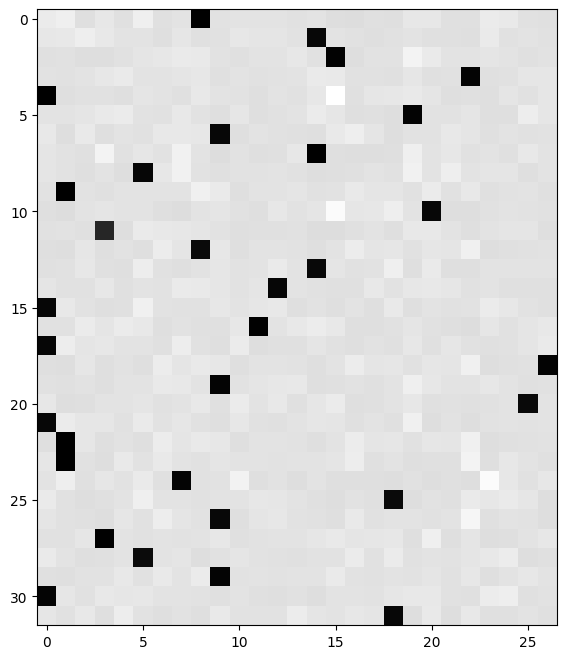

In [33]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray');

## 练习 3 - 化简 BatchNorm

要完成这个挑战，请查看 batchnorm 输出的数学表达式，<br>
对其输入求导，化简该表达式，并直接写出来。<br><br>
BatchNorm 论文：[\[Ioffe, Sergey; Szegedy, Christian. 2015\]](https://arxiv.org/abs/1502.03167)

我们想找到一个单一操作，能够 backprop 通过构成 BatchNorm 的整堆方程。<br>
我们有 `dhpreact`（论文中的 $y_i$），并希望从中*高效地*生成 `dhprebn`。


In [34]:
# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


我们先把 BatchNorm 论文中的方程写出来：
$$\mu_B = \frac{1}{m} \sum_{i=1}^m x_i\\
\sigma_B^2 = \frac{1}{m-1} \sum_{i=1}^m(x_i-\mu_B)^2\ \ \ \ \ \small{(\text{Bessel-corrected})}\\
\hat{x_i} = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2+\epsilon}}\\
y_i = \gamma\hat{x_i}+\beta \equiv BN_{\gamma,\beta}(x_i)$$
我们已有 $\frac{\partial l}{\partial y_i}$，基于此，我们想要 $\frac{\partial l}{\partial x_i}$。

### 第 1 步

第一部分很直接。<br>
对于 $y_i = \gamma\hat{x_i}+\beta$，我们可以推导出 $\frac{\partial l}{\partial \hat{x_i}} = \frac{\partial l}{\partial y_i} \cdot \gamma$。


### 第 2 步

对于 $\frac{\partial l}{\partial \sigma^2}$，我们必须考虑存在许多个 $\hat{x_i}$ 在 $\hat{x}$ 之中。<br>
这些单独的值每一个都各自依赖于 $\sigma^2$。<br>
"从 $\sigma^2$ 指向 $\hat{x}$ 的箭头有很多。"

这就是为什么我们需要对所有 $i$ 对应的 $\hat{x_i}$ 求和。

$$\frac{\partial l}{\partial \sigma^2} = \sum_{i}\left( \frac{\partial l}{\partial \hat{x_i}} \cdot \frac{\partial \hat{x_i}}{\partial \sigma^2}\right) $$

把这个表达式展开，我们得到：

$$= \gamma \cdot \sum_i \frac{\partial}{\partial \sigma^2}\begin{bmatrix}(x_i - \mu)(\sigma^2 + \epsilon)^{-1/2}\end{bmatrix} \cdot \frac{\partial l}{\partial y_i}\\
= \frac{1}{2} \gamma \sum_i (x_i - \mu)(\sigma^2+\epsilon)^{-3/2} \cdot \frac{\partial l}{\partial y_i}$$


### 第 3 步

$\frac{\partial l}{\partial \mu}$ 是什么？<br>
$\mu$ 与 $\hat{x}$ 之间的关系是 $32$ 重的（就像之前 $\sigma^2$ 与 $\hat{x}$ 之间的关系一样）。<br>
$\mu$ 与 $\sigma^2$ 之间的关系是 $1$ 重的，因为 $\sigma^2$ 只是一个标量（*见上文*）。

所有这 $33$ 个流入的梯度都需要在 $\mu$ 中求和。

$$\frac{\partial l}{\partial \mu} = \sum_i \left( \frac{\partial l}{\partial \hat{x}} \cdot \frac{\partial \hat{x_i}}{\partial \sigma^2}\right) + \left( \frac{\partial l}{\partial \sigma^2} \cdot \frac{\partial \sigma^2}{\partial \mu}\right)$$

第一部分是 $32$ 重关系。<br>
相加的第二部分是 $1$ 重关系。

### 第 4 步

现在，每一个 $x_i$（在 $x$ 中）都会发出三个箭头：
- 一个指向 $\mu$ 的箭头
- 一个指向 $\sigma^2$ 的箭头
- 一个指向*每一个单独的* $\hat{x_i}$（位于 $\hat{x}$ 中）的箭头


In [35]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# Getting this python code for the above final equation is not easy
dhprebn = bngain * bnvar_inv / n * (n * dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [ ]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():
  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    # loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, dim=1) # Softmax along the rows of logits
    dlogits[range(n), Yb] -= 1 # At the correct position(s) within dlogits, we need to always subtract a 1
    dlogits /= n               # Scale down gradient by n because of the mean
    # 2nd Linear Layer
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # Tanh
    dhpreact = (1.0 - h**2) * dh
    # Batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain * bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st Linear Layer
    dembcat = dhprebn @ W1.T
    dW1 = dembcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # Embedding Layer
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    # Comment out early breaking below when ready to train full net
    # if i >= 100:
    #   break

12297
      0/ 200000: 3.7918
  10000/ 200000: 2.2118
  20000/ 200000: 2.4945
  30000/ 200000: 2.7126
  40000/ 200000: 2.1289
  50000/ 200000: 2.8434
  60000/ 200000: 2.5684
...
 190000/ 200000: 2.8445


In [41]:
# useful for checking your gradients

# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [42]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [43]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.8233625888824463
val 2.8218600749969482


In [51]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

ernaaimyaahreelmnd.
ryalaretmrsjejdrleg.
adeeedieliihemy.
realekeiseananarneatzimhlkaa.
n.
sadbvrgahimies.
.
n.
...
nsveaoec.


<center>Notebook 作者：<a href="https://github.com/mk2112" target="_blank">mk2112</a>。</center>
